In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import plotly.graph_objects as go
import sys
sys.path.append("../")
from utils import metrics
from scipy import stats
from tqdm import tqdm
from background_removal.main_background_removal import main_background_removal

In [2]:
def compute_grad_magnitude(img):
    grad_x = cv2.Sobel(img, ddepth=cv2.CV_64F, dx=1, dy=0)
    grad_y = cv2.Sobel(img, ddepth=cv2.CV_64F, dx=0, dy=1)
    grad_module = cv2.magnitude(grad_x, grad_y)
    return np.uint8(grad_module)

In [3]:
def get_discriminative_mask(img):
    hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h, s, v = cv2.split(hsv_image)
    edges_s = compute_grad_magnitude(s)

    mask_s = edges_s
    mask_s[mask_s < 75] = 0
    mask_s[mask_s != 0] = 255

    mask = mask_s
    

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(10, 5)))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(5, 10)))

    # plt.imshow(mask,cmap='gray')
    # plt.show()

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

    #For each label except background, get area and pick the two largest (possible two paintings)
    component_info = [(i, stats[i, 4]) for i in range(1, num_labels)]
    component_info.sort(key=lambda c: c[1], reverse=True)
    top_two_labels = [c[0] for c in component_info[:2]]

    new_mask = np.zeros_like(mask)

    for label in top_two_labels:
        
        # Create a mask of only this component
        ys, xs = np.where(labels == label)
        points = np.column_stack((xs, ys))
        
        # Get rotated rectangle from these points
        rect = cv2.minAreaRect(points)
        box = cv2.boxPoints(rect).astype(int)
        
        # Fill the rectangle in the mask
        cv2.fillPoly(new_mask, [box], 255)
        
    # plt.imshow(new_mask,cmap='gray')
    # plt.show()  
    
    return new_mask

def get_masks(img) -> list:
    
    AREA_THRESHOLD = (0.2*img.shape[0]) * (0.2*img.shape[1])
    discriminative_mask = get_discriminative_mask(img)

    # Check if there is more than one painting (big area)
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(discriminative_mask)
    small_areas = np.sum(stats[1:, 4] < AREA_THRESHOLD)
    # print(num_labels - small_areas - 1)
    if num_labels - small_areas - 1 > 1:
        
        #Sort stats from left painting to right painting (in case there are more than 2 in the future)
        stats_no_background = stats[1:]
        stats_no_background = stats_no_background[np.argsort(stats_no_background[:, 0])]
        
        #Compute their distances to get their image slice
        left_painting_x = stats_no_background[0, 0] + stats_no_background[0, 2]
        right_painting_x = stats_no_background[1, 0]
        distance = right_painting_x - left_painting_x
        middle_pos = left_painting_x + distance//2

        
        left_painting = img[:, 0:middle_pos]
        right_painting = img[:, middle_pos:]
        
        _, left_mask = main_background_removal(left_painting)
        _, right_mask = main_background_removal(right_painting)
        return [left_mask, right_mask]

    # print("Doing single mask")
    # plt.imshow(img)
    # plt.show()
    _, mask = main_background_removal(img)
    return [mask]

In [4]:
def has_impulse_noise(img, diff_threshold=60, ratio_threshold=0.01):
    median = cv2.medianBlur(img, 3)
    diff = cv2.absdiff(img, median)
    noisy_pixels = np.any(diff > diff_threshold, axis=2)
    noise_ratio = np.sum(noisy_pixels) / noisy_pixels.size
    return noise_ratio > ratio_threshold

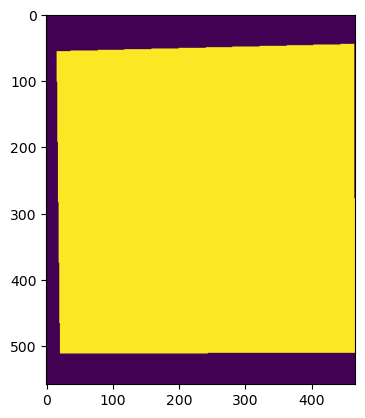

Hola


In [5]:
img1 = cv2.imread("../data/qsd2_w3/00022.jpg", cv2.IMREAD_UNCHANGED)
if has_impulse_noise(img1):
    img1 = cv2.medianBlur(img1, 3)
masks = get_masks(img1)
_, mask = main_background_removal(img1)
plt.imshow(mask)
plt.show()
print("Hola")

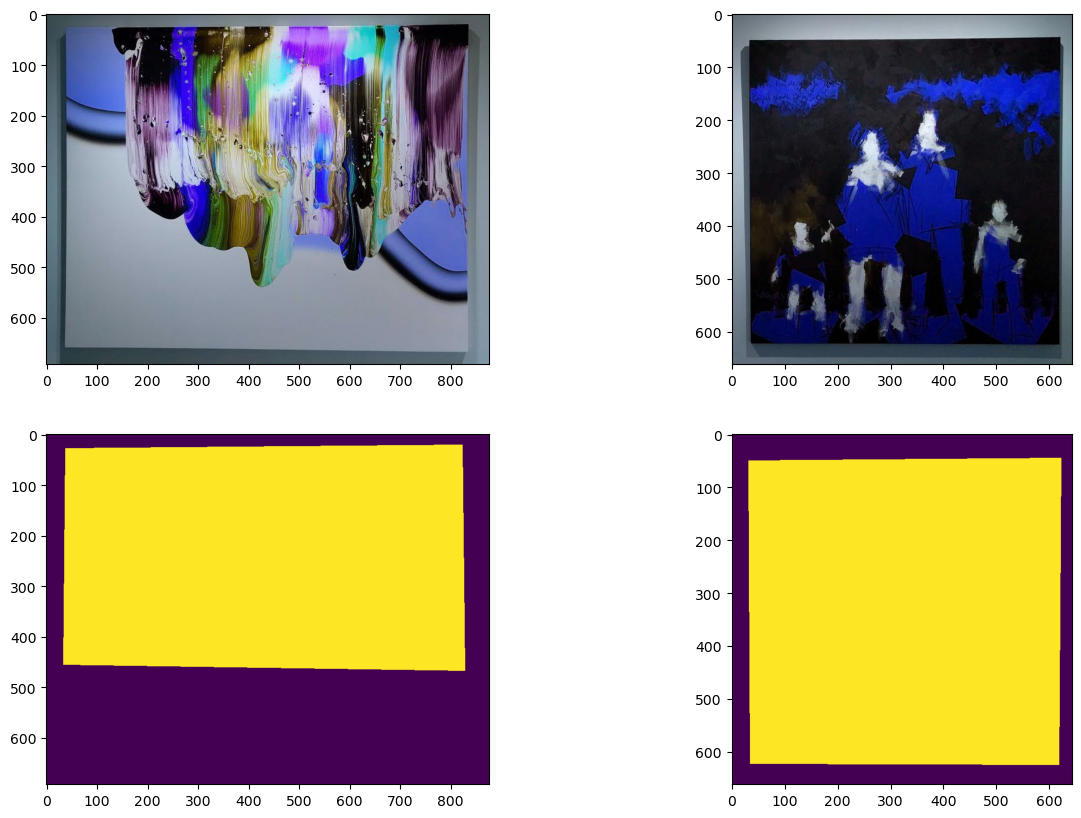

In [6]:
img1 = cv2.imread("../data/qsd2_w3/00021.jpg", cv2.IMREAD_UNCHANGED)
img2 = cv2.imread("../data/qsd2_w3/00009.jpg", cv2.IMREAD_UNCHANGED)
f, ax = plt.subplots(2, 2, figsize=(15,10))
ax[0][0].imshow(img1)
_, mask = main_background_removal(img1)
ax[1][0].imshow(mask)
ax[0][1].imshow(img2)
_, mask = main_background_removal(img2)
ax[1][1].imshow(mask)
plt.show()

  0%|          | 0/30 [00:00<?, ?it/s]

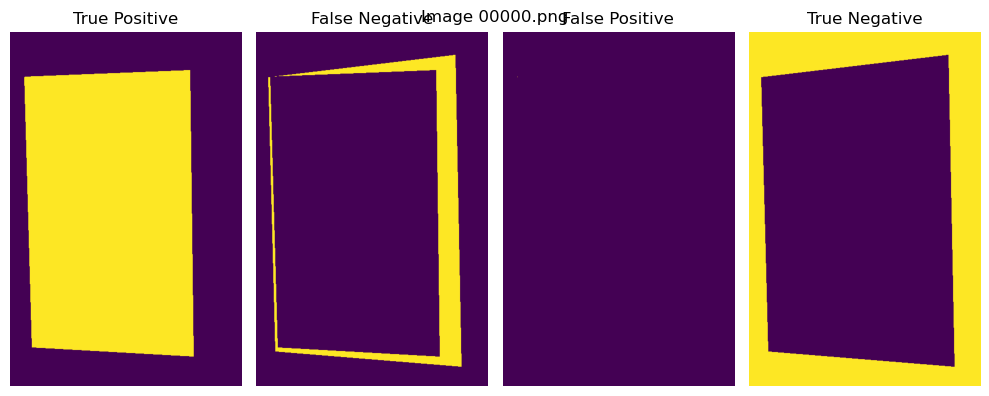

  3%|▎         | 1/30 [00:00<00:07,  3.82it/s]

Precision: 0.9999943649590615
Recall: 0.8339520851151818
F_score: 0.9094566373268761


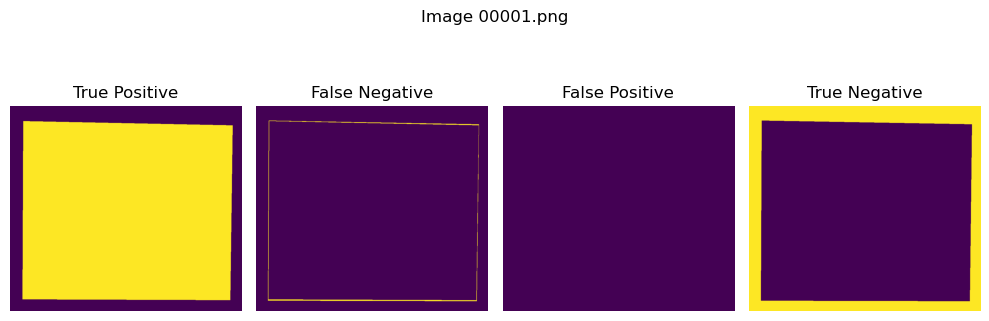

  7%|▋         | 2/30 [00:00<00:09,  2.87it/s]

Precision: 1.0
Recall: 0.9845463086695638
F_score: 0.9922129852737998


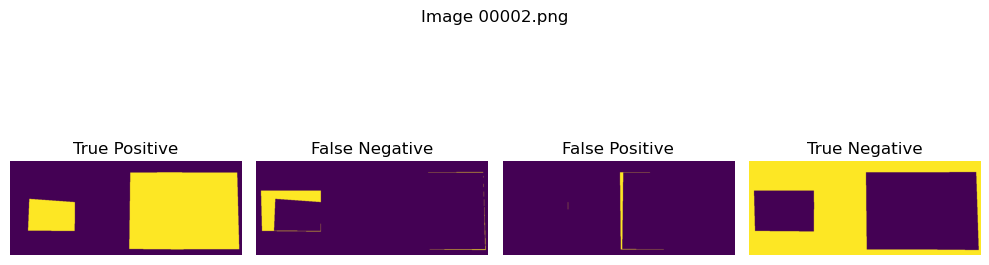

 10%|█         | 3/30 [00:00<00:08,  3.27it/s]

Precision: 0.9792672751637127
Recall: 0.9003911358049087
F_score: 0.9381742650643268


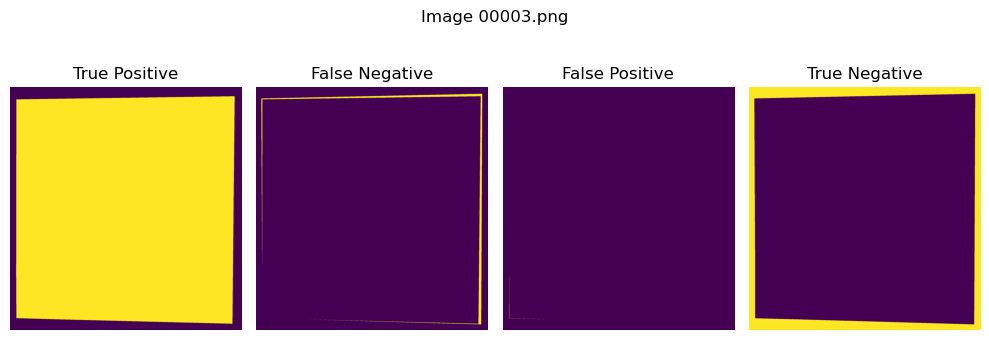

 13%|█▎        | 4/30 [00:02<00:22,  1.14it/s]

Precision: 0.9997921690414444
Recall: 0.9796906472476931
F_score: 0.9896393433084661


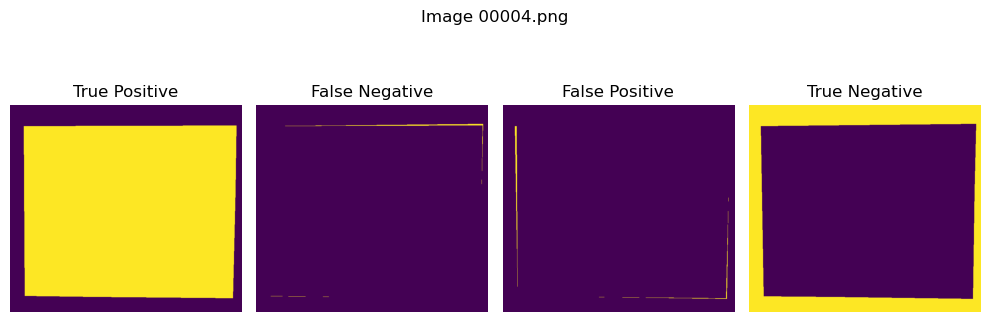

 17%|█▋        | 5/30 [00:03<00:17,  1.46it/s]

Precision: 0.9928827528666299
Recall: 0.9944580898337144
F_score: 0.99366979697651


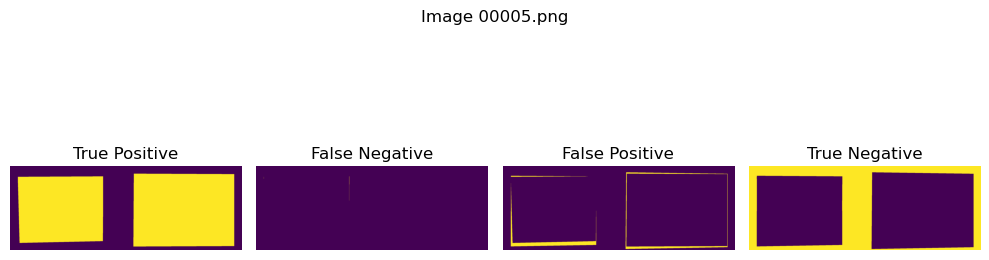

 20%|██        | 6/30 [00:03<00:17,  1.37it/s]

Precision: 0.9438504140955233
Recall: 0.9996975870003783
F_score: 0.9709716260453128


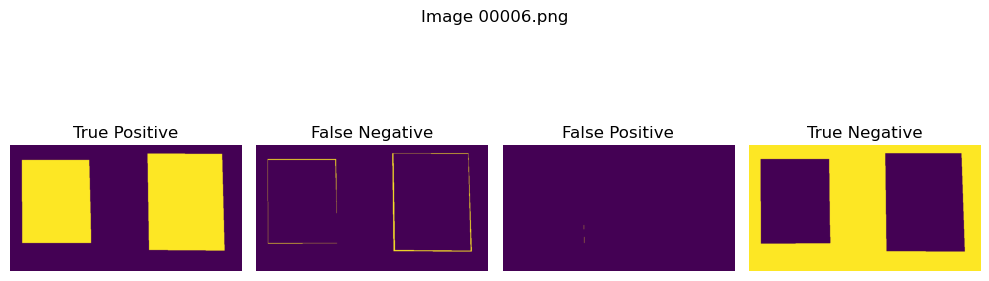

 23%|██▎       | 7/30 [00:04<00:13,  1.75it/s]

Precision: 0.9997561098079724
Recall: 0.9647593864215306
F_score: 0.9819460247788608


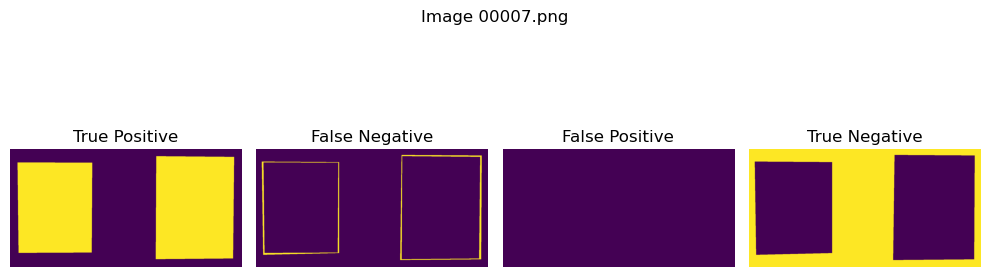

 27%|██▋       | 8/30 [00:04<00:12,  1.81it/s]

Precision: 1.0
Recall: 0.9438431452546183
F_score: 0.9711103980367584


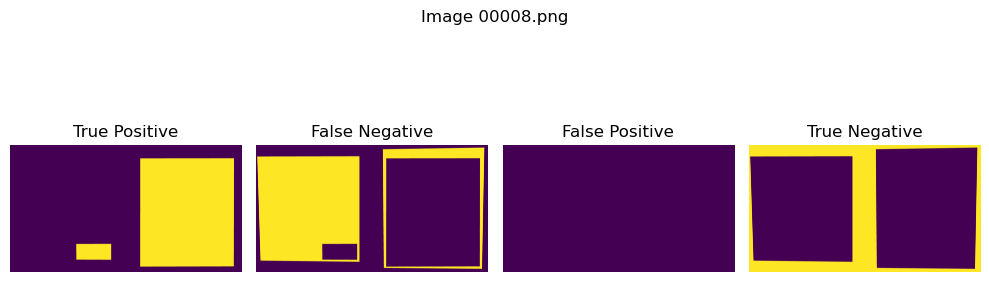

 30%|███       | 9/30 [00:08<00:34,  1.66s/it]

Precision: 1.0
Recall: 0.4738923047474134
F_score: 0.6430487535907533


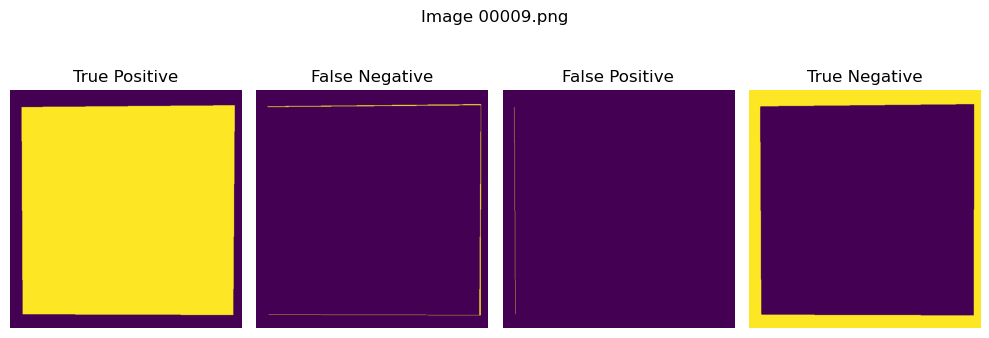

 33%|███▎      | 10/30 [00:08<00:24,  1.24s/it]

Precision: 0.9983110642943103
Recall: 0.9897664188008507
F_score: 0.9940203793440876


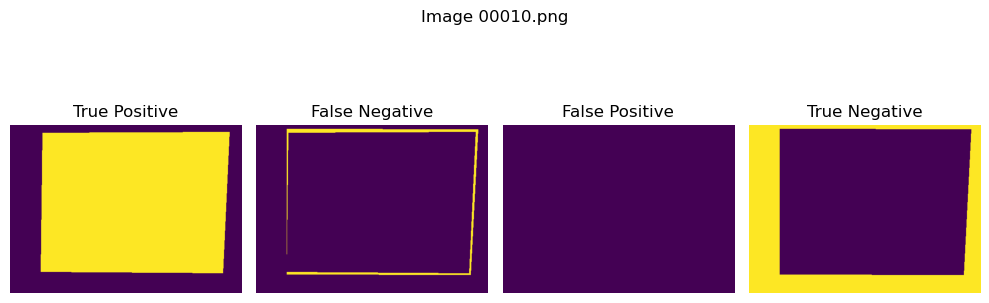

 37%|███▋      | 11/30 [00:09<00:17,  1.08it/s]

Precision: 1.0
Recall: 0.9466019076269936
F_score: 0.9725685605445125


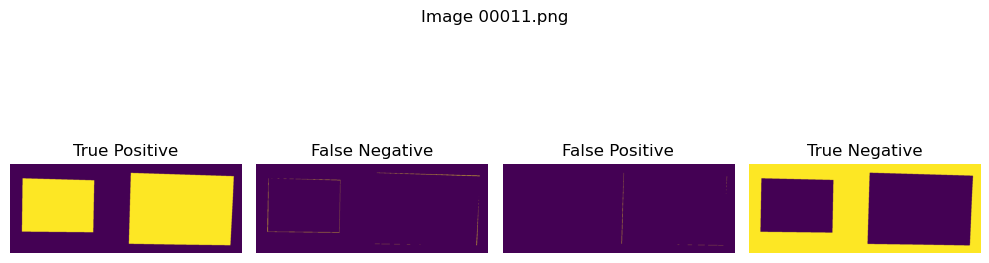

 40%|████      | 12/30 [00:09<00:14,  1.28it/s]

Precision: 0.9978540299406918
Recall: 0.9904608830552408
F_score: 0.9941437115372178


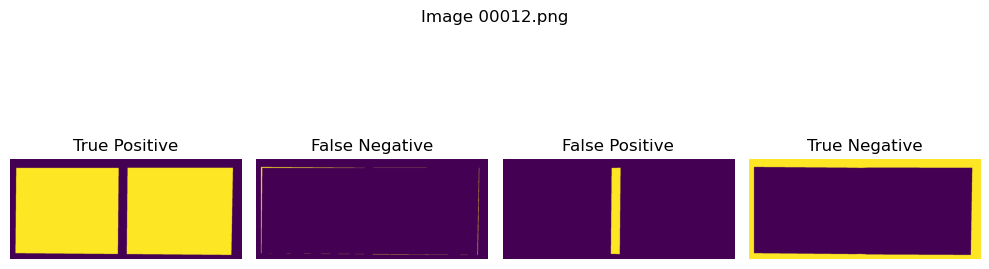

 43%|████▎     | 13/30 [00:10<00:12,  1.35it/s]

Precision: 0.9588814729997804
Recall: 0.9890571968253667
F_score: 0.9737356072489405


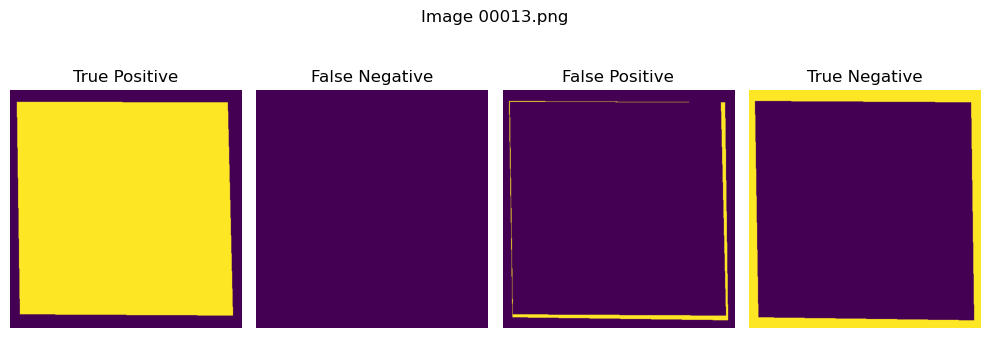

 47%|████▋     | 14/30 [00:10<00:09,  1.68it/s]

Precision: 0.9628536237267591
Recall: 1.0
F_score: 0.9810753202255025


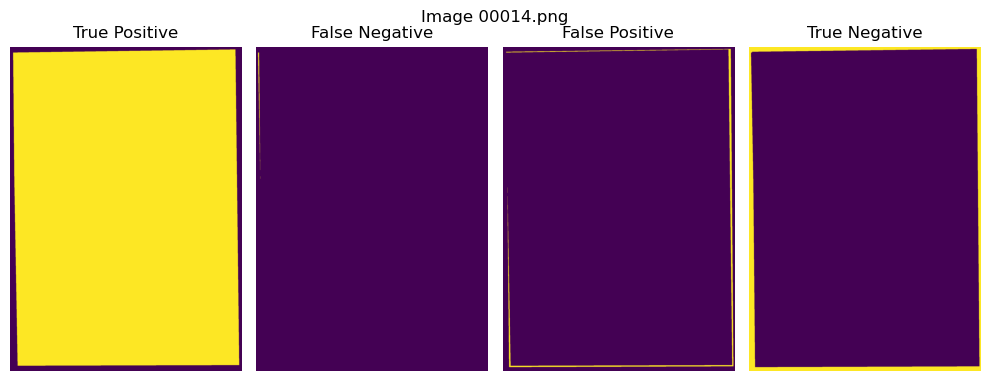

 50%|█████     | 15/30 [00:12<00:13,  1.14it/s]

Precision: 0.9839761824651556
Recall: 0.9989893556270878
F_score: 0.9914259361450803


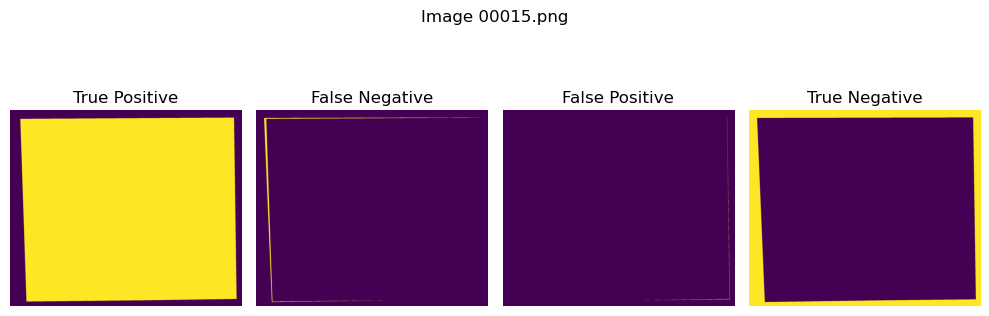

 53%|█████▎    | 16/30 [00:13<00:14,  1.05s/it]

Precision: 0.9986538884663819
Recall: 0.9897777250998924
F_score: 0.9941959956225291


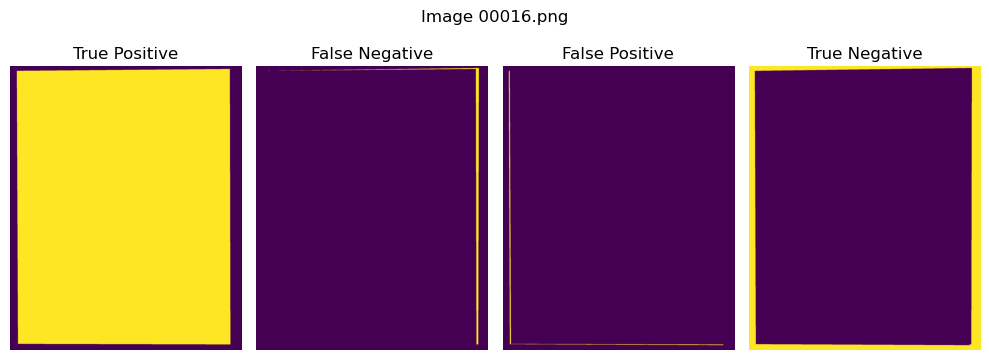

 57%|█████▋    | 17/30 [00:15<00:16,  1.25s/it]

Precision: 0.9932043267118815
Recall: 0.98696649078893
F_score: 0.9900755836896944


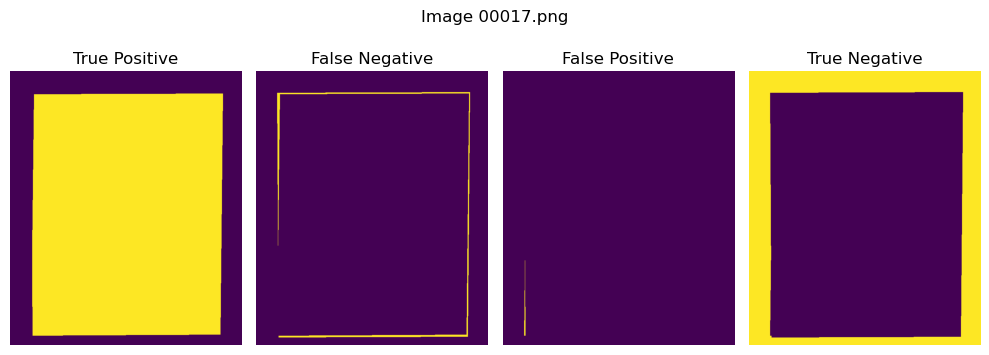

 60%|██████    | 18/30 [00:15<00:11,  1.01it/s]

Precision: 0.9987058352264928
Recall: 0.974681917842673
F_score: 0.9865476435893425


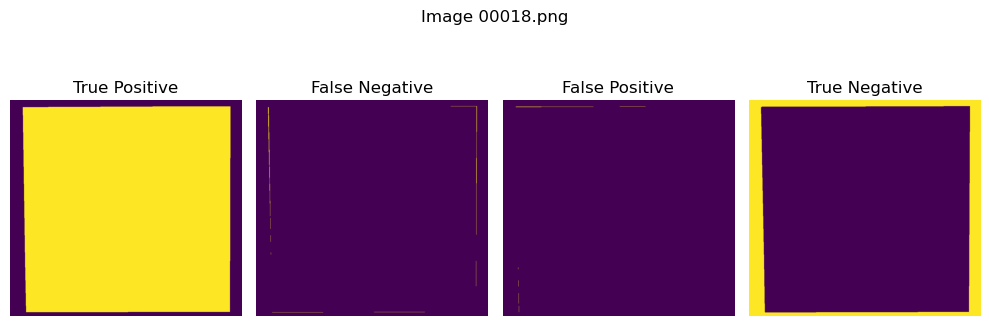

 63%|██████▎   | 19/30 [00:16<00:09,  1.22it/s]

Precision: 0.9990729537722172
Recall: 0.9965893441541911
F_score: 0.9978296035322108


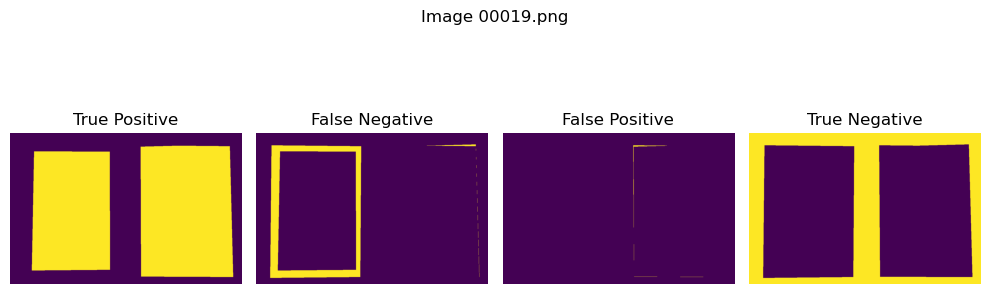

 67%|██████▋   | 20/30 [00:16<00:07,  1.41it/s]

Precision: 0.9968780717586863
Recall: 0.883334433623739
F_score: 0.936677874855193


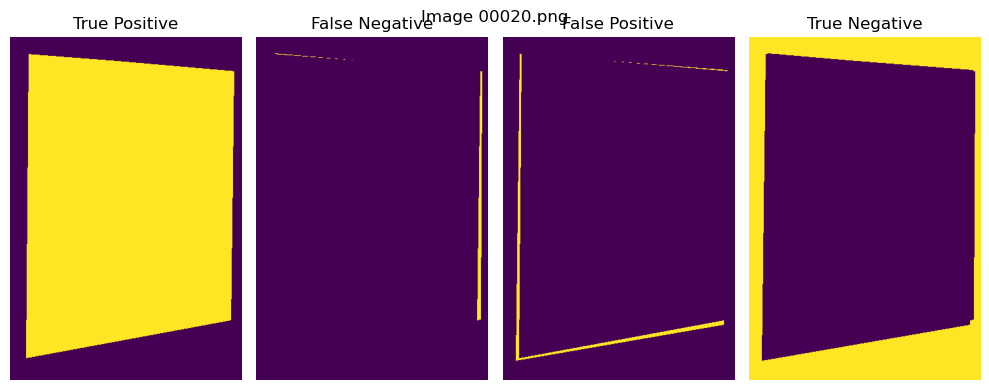

 70%|███████   | 21/30 [00:16<00:05,  1.78it/s]

Precision: 0.9741104441946453
Recall: 0.9870268489068454
F_score: 0.980526111662628


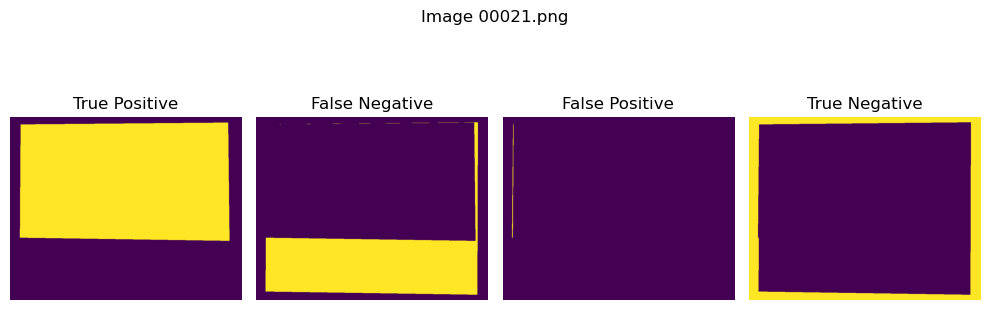

 73%|███████▎  | 22/30 [00:17<00:04,  1.96it/s]

Precision: 0.9967112190703136
Recall: 0.6724741320917775
F_score: 0.8031013590237994


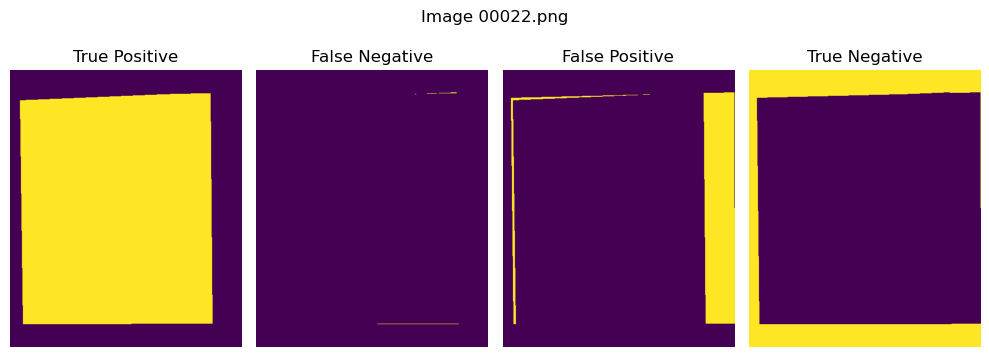

 77%|███████▋  | 23/30 [00:17<00:03,  2.33it/s]

Precision: 0.8498629206395419
Recall: 0.9986657391463011
F_score: 0.9182751669231354


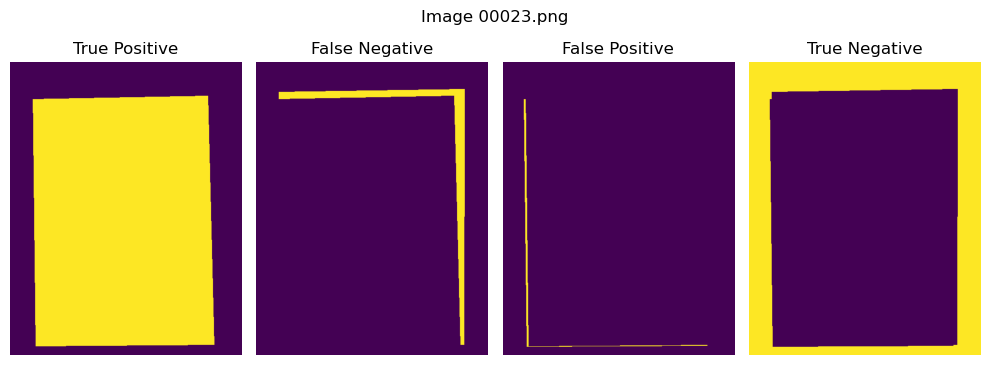

 80%|████████  | 24/30 [00:17<00:02,  2.64it/s]

Precision: 0.9861864309373792
Recall: 0.9344098370393839
F_score: 0.9596002216472047


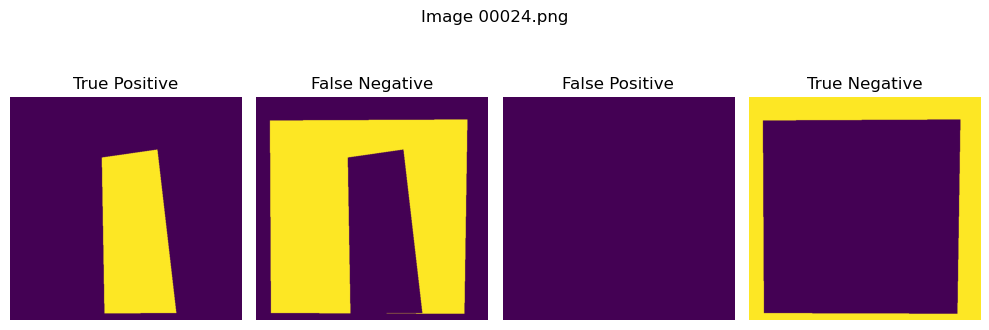

 83%|████████▎ | 25/30 [00:18<00:02,  2.45it/s]

Precision: 1.0
Recall: 0.2705814239603989
F_score: 0.4259174876286123


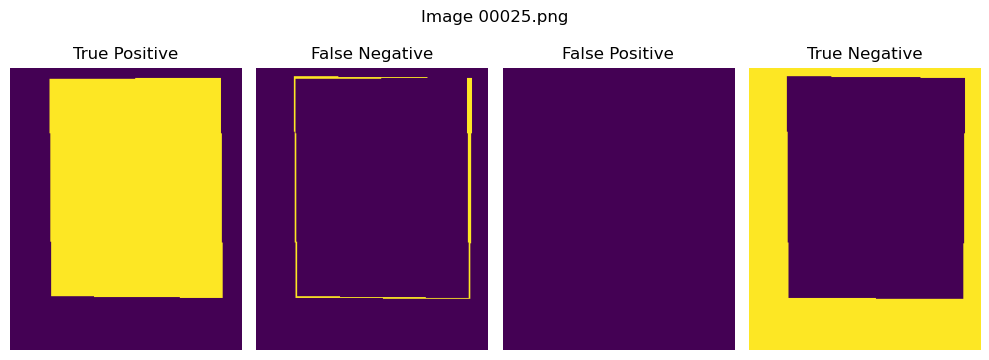

 87%|████████▋ | 26/30 [00:18<00:01,  3.00it/s]

Precision: 1.0
Recall: 0.9603505918496431
F_score: 0.9797743279619455


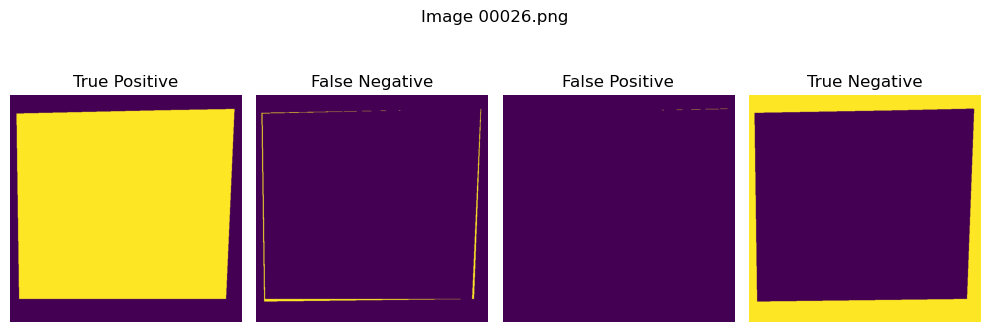

 90%|█████████ | 27/30 [00:18<00:01,  2.88it/s]

Precision: 0.9996911714631874
Recall: 0.9814940071266602
F_score: 0.9905090189165793


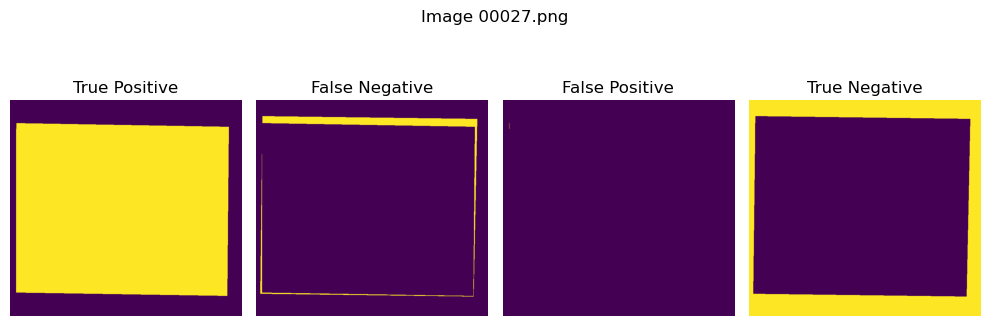

 93%|█████████▎| 28/30 [00:19<00:00,  2.82it/s]

Precision: 0.9999509137787607
Recall: 0.9432405823378319
F_score: 0.9707682275337964


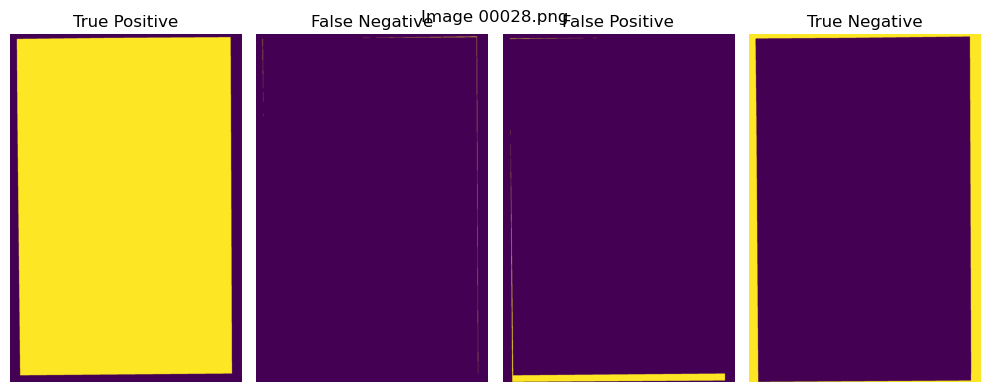

 97%|█████████▋| 29/30 [00:20<00:00,  1.24it/s]

Precision: 0.9784268078713252
Recall: 0.998203182324583
F_score: 0.988216062827257


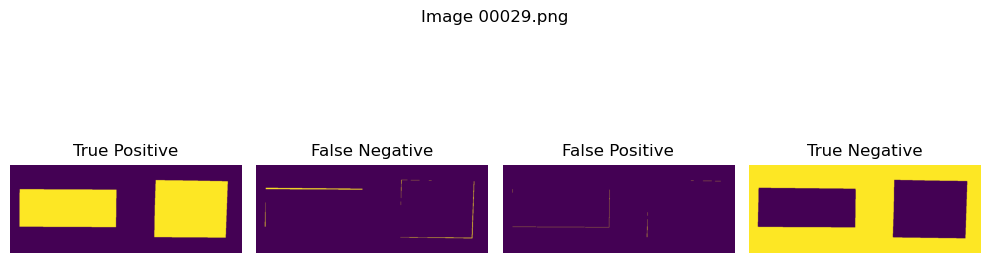

100%|██████████| 30/30 [00:21<00:00,  1.42it/s]

Precision: 0.9944740601372775
Recall: 0.9746356521382814
F_score: 0.9844549220331733
Average F_score : 0.9401222984298034
Average Precision : 0.9861116167796379
Average Recall : 0.9180846120153893


In [8]:
score = 0
precision = 0
recall = 0

for i in tqdm(range(30)):
    img = cv2.imread(f"../data/qsd2_w3/{i:05d}.jpg", cv2.IMREAD_UNCHANGED)
    if has_impulse_noise(img):
        img = cv2.medianBlur(img, 3)
    correct_img = cv2.imread(f"../data/qsd2_w3/{i:05d}.png", cv2.IMREAD_UNCHANGED)
    
    masks = get_masks(img)
    result = masks[0]
    if len(masks) > 1:
        left_mask = masks[0]
        right_mask = masks[1]
        result = np.column_stack([left_mask, right_mask])
    
    TP = np.sum(correct_img & result)
    FN = np.sum(correct_img & (255 - result))
    FP = np.sum((255 - correct_img) & result)
    TN = np.sum((255 - correct_img) & (255 - result))
    
    f, ax = plt.subplots(1, 4, figsize=(10, 8))
    f.suptitle(f"Image {i:05d}.png")
    plt.axis('off')
    ax[0].imshow(correct_img & result)
    ax[0].axis('off')
    ax[0].set_title("True Positive")
    
    ax[1].imshow(correct_img & (255 - result))
    ax[1].axis('off')
    ax[1].set_title("False Negative")
    
    ax[2].imshow((255 - correct_img) & result)
    ax[2].axis('off')
    ax[2].set_title("False Positive")
    
    ax[3].imshow((255 - correct_img) & (255 - result))
    ax[3].axis('off')
    ax[3].set_title("True Negative")
    
    plt.tight_layout(rect=[0, 0, 1, 1.5])
    
    plt.show()
    
    
    P = TP / (TP + FP)
    R = TP / (TP + FN)
    F_score = 2*(P*R/(P + R))
    
    score = score + F_score
    precision += P
    recall += R
    
    print(f"Precision: {P}\nRecall: {R}\nF_score: {F_score}")
    
print(f"Average F_score : {score/30}")
print(f"Average Precision : {precision/30}")
print(f"Average Recall : {recall/30}")